# Análisis de Correlación y Asociación

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/02_eda/03_analisis_correlacion_y_asociacion.ipynb)

## Objetivos

- Comprender por qué analizar relaciones entre variables es un paso fundamental antes de entrenar modelos de Machine Learning.
- Diferenciar entre correlación lineal, monotónica y relaciones no lineales.
- Utilizar métricas de correlación comunes como Pearson y Spearman para explorar dependencias entre variables.
- Interpretar matrices de correlación y detectar posibles problemas de multicolinealidad.
- Aplicar Información Mutua (*Mutual Information*) para detectar relaciones más complejas entre variables y el objetivo.

## Prerrequisitos

- [Tipos de Datos y Datasets](../01_introduccion/04_tipos_de_datos_y_datasets.ipynb).
- Haber completado [Feature Engineering Básico y Limpieza de Datos](02_feature_engineering_basico_y_limpieza.ipynb).
- Concepto de *Data Leakage*.
- Manipulación básica de datos con Pandas (`DataFrame`, selección de columnas).
- Conceptos básicos de *features* y variable objetivo (*target*) en Machine Learning.
- Visualización básica de datos con `Matplotlib` o `Seaborn` (*scatter plots*).

---
## Configuración del Entorno

In [ ]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

# Detectar Google Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Ejecución en Google Colab. Clonando repositorio...")
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

# Importar utilidades globales
from utils.plots import setup_plot_style
setup_plot_style()

Ejecución en Google Colab. Clonando repositorio...


## 1. La Importancia de Entender las Relaciones



En *machine learning*, no todas las características (*features*) aportan la misma información. Algunas variables son redundantes (dos sensores midiendo lo mismo de forma distinta), y otras simplemente no tienen relación con lo que intentamos predecir.

Antes de alimentar un modelo, un ingeniero de IA debe entender matemáticamente cómo interactúan las variables. Esto permite:
1. **Reducir dimensionalidad:** Eliminar características redundantes.
2. **Evitar Multicolinealidad:** En modelos como la Regresión Lineal, tener variables muy correlacionadas entre sí vuelve inestable al modelo.
3. **Descubrir *Insights* de Negocio:** Encontrar qué variables impulsan el comportamiento del objetivo, realizar optimizaciones con ello, etc.



## 2. Tipos de Correlación: No todo es Línea Recta


Cuando hablamos de "correlación", usualmente pensamos en la **Correlación de Pearson**. Sin embargo, existen diferentes métricas según el tipo de relación matemática que busquemos.


Generamos varios escenarios para probar estas cosas:

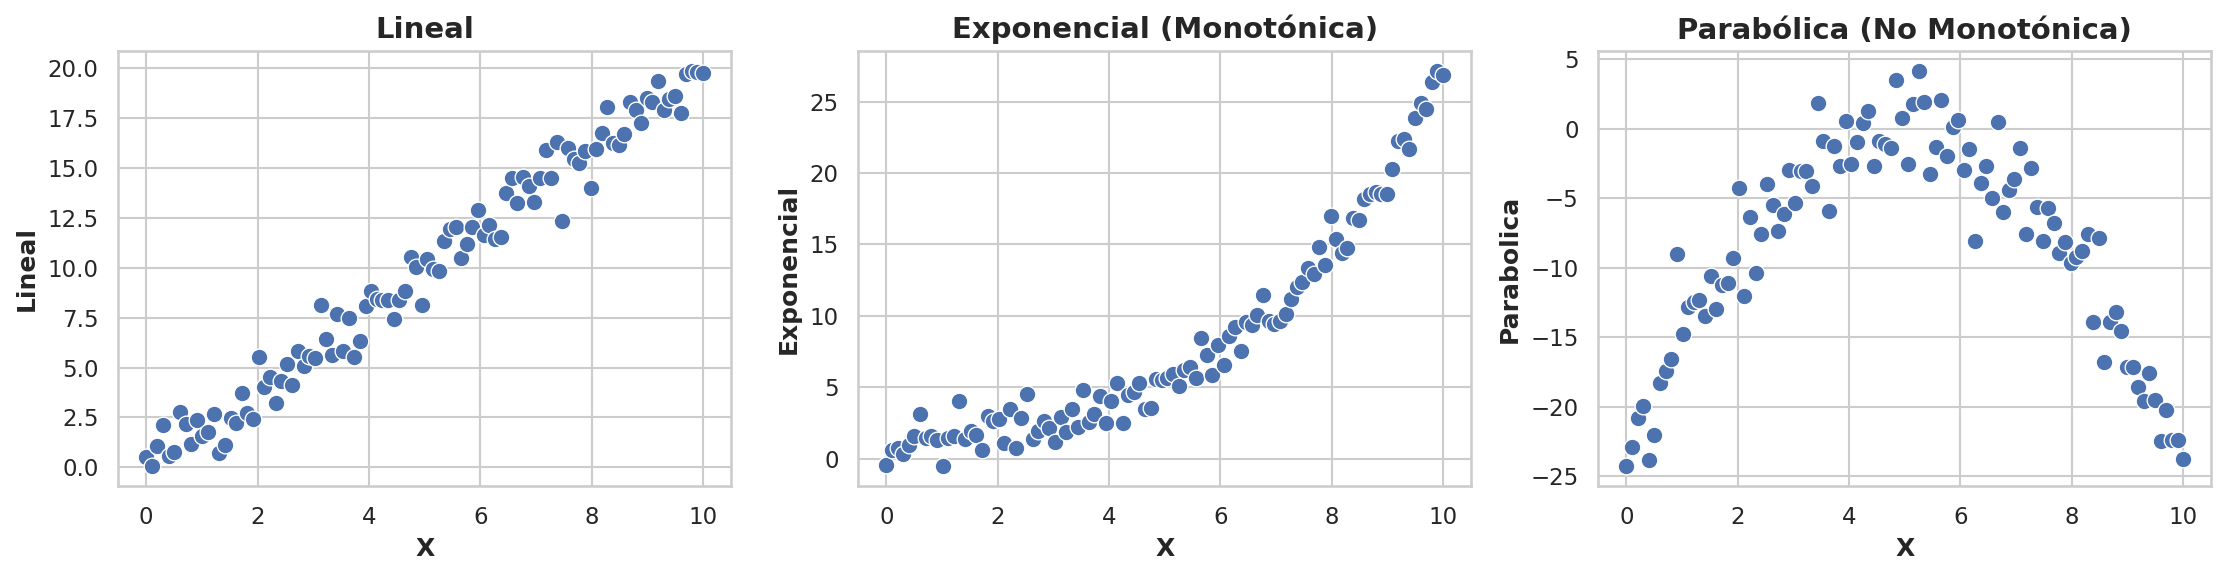

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generación de datos sintéticos para ilustrar los conceptos
np.random.seed(42)
x = np.linspace(0, 10, 100)

# 1. Relación Lineal (Pearson brillará aquí)
y_lineal = 2 * x + np.random.normal(0, 1, 100)

# 2. Relación Monotónica no lineal (Spearman brillará aquí)
y_exp = np.exp(x/3) + np.random.normal(0, 1, 100)

# 3. Relación No Monotónica (Ambos fallarán)
y_para = -(x - 5)**2 + np.random.normal(0, 2, 100)

df_corr = pd.DataFrame({'X': x, 'Lineal': y_lineal, 'Exponencial': y_exp, 'Parabolica': y_para})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(x='X', y='Lineal', data=df_corr, ax=axes[0]).set_title('Lineal')
sns.scatterplot(x='X', y='Exponencial', data=df_corr, ax=axes[1]).set_title('Exponencial (Monotónica)')
sns.scatterplot(x='X', y='Parabolica', data=df_corr, ax=axes[2]).set_title('Parabólica (No Monotónica)')
plt.tight_layout()
plt.show()


### Pearson vs Spearman vs Kendall



Veamos cómo los distintos algoritmos de Pandas evalúan estas tres relaciones.



In [3]:
print("--- Correlación de PEARSON (Relación Lineal) ---")
display(df_corr.corr(method='pearson')[['X']].T)

print("\n--- Correlación de SPEARMAN (Relación Monotónica - Basada en rangos) ---")
display(df_corr.corr(method='spearman')[['X']].T)


--- Correlación de PEARSON (Relación Lineal) ---


,X,Lineal,Exponencial,Parabolica
X,1.0,0.988388,0.920341,-0.025609



--- Correlación de SPEARMAN (Relación Monotónica - Basada en rangos) ---


,X,Lineal,Exponencial,Parabolica
X,1.0,0.988011,0.965521,-0.02183



**Análisis de Resultados:**
- **Relación Lineal:** Tanto Pearson como Spearman detectan una relación casi perfecta (`~0.99`).
- **Relación Exponencial:** Pearson baja a `0.92` porque los puntos no forman una línea recta. Sin embargo, Spearman es `0.96` porque evalúa el *rango*: "Siempre que X sube, Y también sube", sin importar a qué velocidad.
- **Relación Parabólica:** ¡Ambos dan cerca de `0.0`! Esto es un gran peligro. **Correlación 0 no implica independencia**. Significa que no hay relación *lineal* ni *monotónica*, pero claramente hay un patrón cuadrático perfecto (ver la figura a la derecha).

> ⚠️ **Advertencia:** Nunca confiar ciegamente en una matriz de correlación sin hacer un *scatter plot*. Una correlación cercana a cero podría estar ocultando una relación altamente predictiva pero no lineal (como el caso de la parábola).

## 3. Matriz de Correlación en un Caso Real


Utilizamos el *dataset* de resistencia del hormigón (CCS) para ver esto en un entorno multivariado.

Archivo CSV no encontrado. Descomprimiendo /content/applied-ai-engineering/datasets/ccs/datos_ccs.zip...
Descompresión completa. Intentando cargar el CSV.
Dataset cargado exitosamente con 1030 filas y 9 columnas.


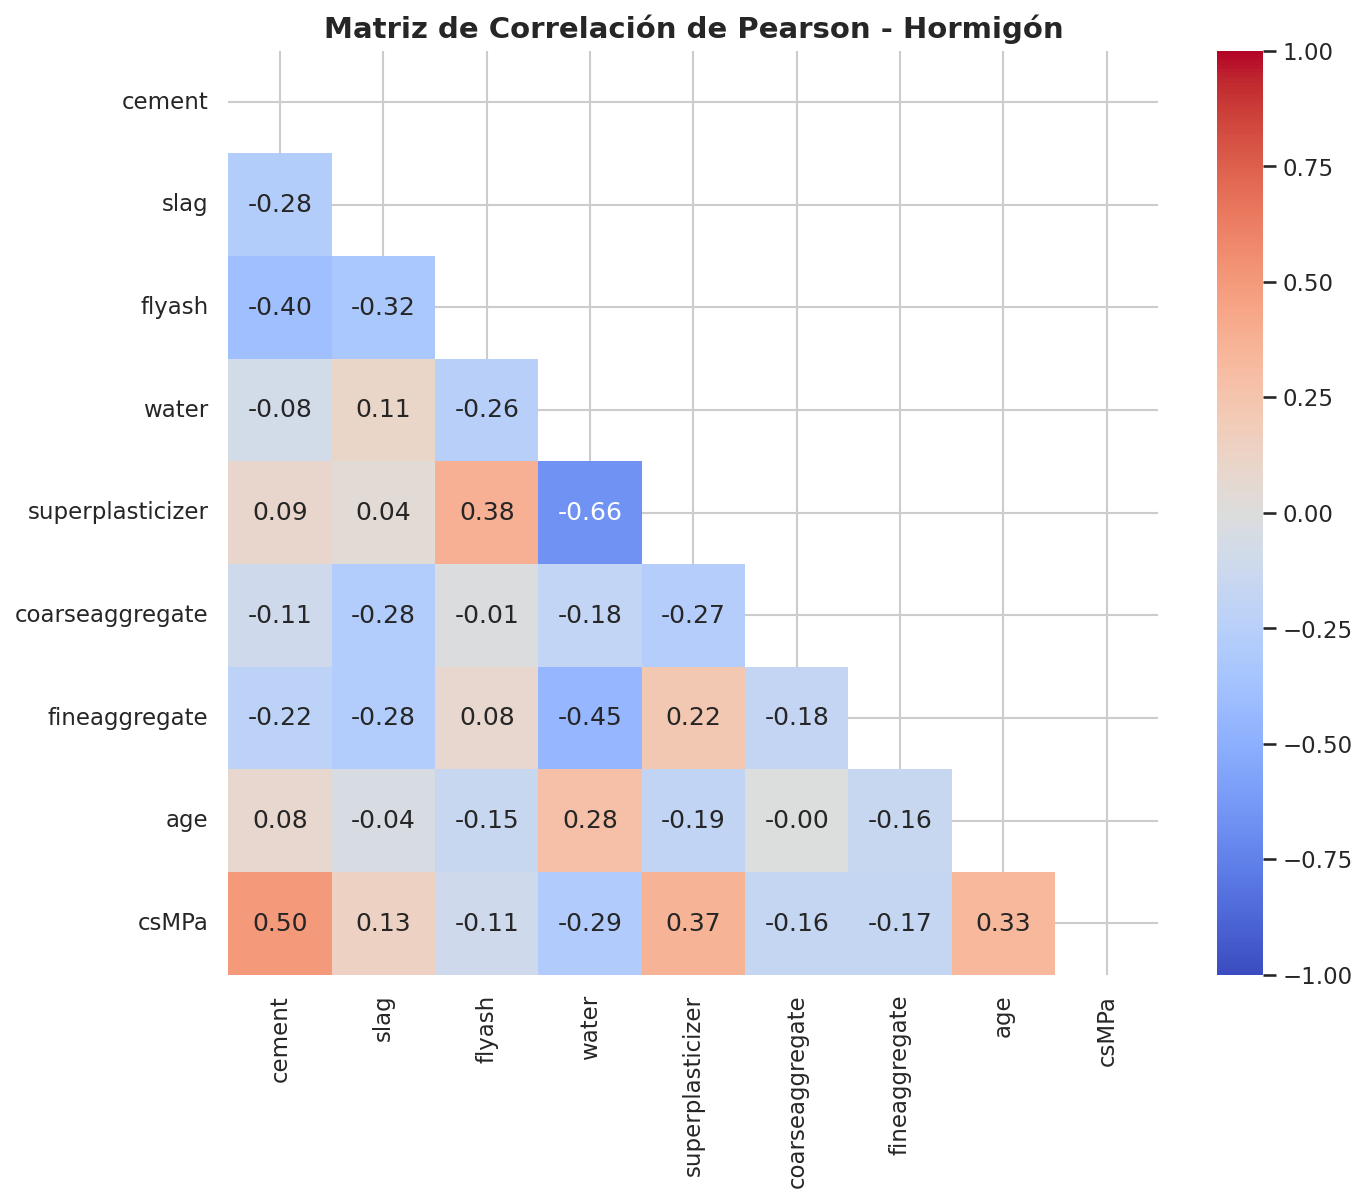

In [4]:
from utils.data import load_dataset

df_ccs = load_dataset("datasets/ccs/datos_ccs.csv")

# Calculamos Pearson (por defecto)
corr_matrix = df_ccs.corr()

plt.figure(figsize=(10, 8))
# Usar una máscara para ocultar la mitad superior (espejo) y hacerla más legible
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Matriz de Correlación de Pearson - Hormigón")
plt.show()



**Lectura de la Matriz:**
1. **Correlación con el Target (`csMPa`):** El `cement` tiene una fuerte correlación positiva (`0.50`), mientras que el `water` tiene una correlación negativa (`-0.29`). Tiene sentido en la ingeniería civil: más agua debilita la mezcla.
2. **Multicolinealidad (Variables independientes correlacionadas entre sí):** `superplasticizer` y `water` tienen una correlación de `-0.66`. Si usamos mucha agua, necesitamos menos plastificante. Mantener ambas variables podría ser redundante para un modelo lineal simple.



## 4. Información Mutua (*Mutual Information*)



Como vimos con la parábola, la correlación falla si la relación no es una línea o una curva que siempre sube/baja. Para medir **cualquier** tipo de dependencia (incluso complejas o categóricas), la Teoría de la Información nos da la **Información Mutua (MI)**.

MI mide cuánto se reduce nuestra incertidumbre sobre una variable (ej. `Y`) al conocer otra (`X`).
- `MI = 0`: Son totalmente independientes.
- `MI > 0`: Existe dependencia (mientras mayor, más fuerte). A diferencia de la correlación, no tiene un límite superior fijo en 1.



In [ ]:
from sklearn.feature_selection import mutual_info_regression

# Volvemos a nuestro dataset de juguete donde Pearson falló con la parábola
mi_scores = mutual_info_regression(df_corr[['X']], df_corr['Parabolica'])
print(f"Correlación Pearson (X vs Parábola): {df_corr['X'].corr(df_corr['Parabolica']):.4f}")
print(f"Información Mutua (X vs Parábola): {mi_scores[0]:.4f}")

Correlación Pearson (X vs Parábola): -0.0256
Información Mutua (X vs Parábola): 1.1066



La correlación dice "0 relación". La Información Mutua detecta una señal fuertísima.



### Información Mutua en el Dataset Real


/tmp/ipykernel_180/1898388725.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mutual Information', y='Feature', data=df_mi, palette='viridis')


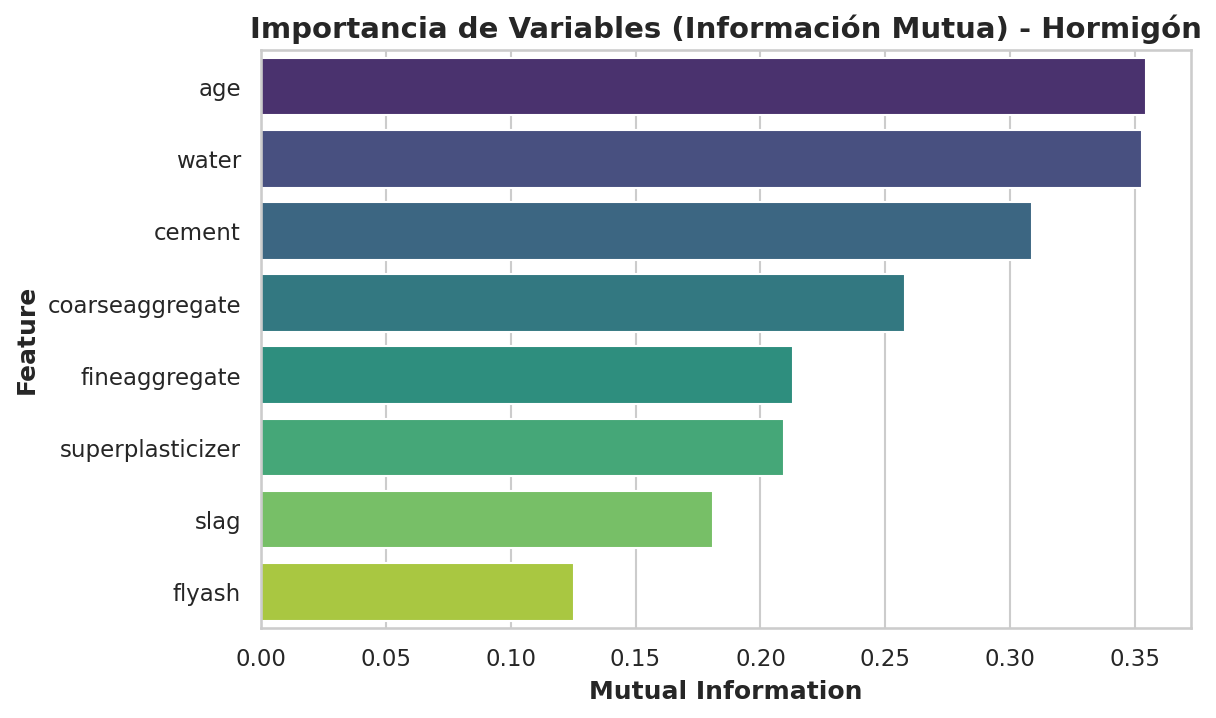

In [ ]:
X_ccs = df_ccs.drop('csMPa', axis=1)
y_ccs = df_ccs['csMPa']

# Calculamos MI para todas las características
mi_scores = mutual_info_regression(X_ccs, y_ccs, random_state=42)

df_mi = pd.DataFrame({
    'Feature': X_ccs.columns,
    'Mutual Information': mi_scores
}).sort_values(by='Mutual Information', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Mutual Information', y='Feature', data=df_mi, palette='viridis')
plt.title("Importancia de Variables (Información Mutua) - Hormigón")
plt.show()


Observar cómo `age` (edad del cemento) tiene la mayor Información Mutua, ¡pero en la matriz de Pearson solo tenía `0.33`! Esto indica que la relación entre la edad del cemento y su resistencia es **altamente no lineal** (el cemento cura rápido al principio y luego se estabiliza). Un modelo lineal sufrirá para captar esto si no aplicamos transformaciones, mientras que un Random Forest lo captará perfectamente.

**NOTA**: No se preocupen, más adelante vemos en detalle cómo funcionan y qué hacen los modelos de *machine learning* que venimos mencionando.

## Referencias


1. [Correlación en `Pandas`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html)
2. [Información Mutua en `scikit-learn`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_regression.html)

## Conexiones y Próximos Pasos
- ➡️ **Siguiente:** Vimos que la correlación lineal falla con relaciones complejas (como la parábola). En el próximo *notebook* aprendemos a "doblar el espacio" matemático para solucionar esto en [Transformaciones y Feature Engineering Avanzado](04_transformaciones_y_fe_avanzado.ipynb).

## Entorno de Ejecución


In [ ]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.12
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
